# 02 · Geometry

[Index](./00_index.ipynb) · [← Previous](./01_inventory_properties.ipynb) · [Next →](./03_spatial_graphs.ipynb)

The IFC sample model `AC20-FZK-Haus.ifc` is provided as part of the KIT IFC example dataset, developed by the Institute for Automation and Applied Informatics (IAI) at Karlsruhe Institute of Technology (KIT). It is distributed for unrestricted use and commonly referenced in IFC tutorials, including IfcOpenShell documentation and sample workflows.

This notebook is standalone: it re-downloads and re-opens the model so it can run on its own in Colab, independent of the other notebooks in this portfolio.

In [5]:
!pip install -q ifcopenshell numpy pandas matplotlib

In [4]:
pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 1.7 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 2.0 MB/s eta 0:00:01
   ---------------------------- ----------- 1.3/1.8 MB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.0 MB/s  0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 26.0.1
    Uninstalling pip-26.0.1:
      Successfully uninstalled pip-26.0.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
import ifcopenshell
import ifcopenshell.geom
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [3]:
# Load the sample IFC model
import ifcopenshell
import requests

r = requests.get("https://www.ifcwiki.org/images/e/e3/AC20-FZK-Haus.ifc")
with open("model.ifc", "w") as f:
    f.write(r.text)

model = ifcopenshell.open("model.ifc")

print("Schema:", model.schema)
print("Walls:", len(model.by_type("IfcWall")))

Schema: IFC4
Walls: 13


## Geometry
<a id="geometry"></a>

In [4]:
# Geometry settings
settings = ifcopenshell.geom.settings()
settings.set(settings.USE_WORLD_COORDS, True)

### Case: Wall

In [5]:
# Get a wall
wall = model.by_type("IfcWall")[0]
print("Picked Wall:", wall)

# Create shape
wall_shape = ifcopenshell.geom.create_shape(settings, wall)

Picked Wall: #15042=IfcWallStandardCase('2XPyKWY018sA1ygZKgQPtU',#12,'Wand-Int-ERDG-4',$,$,#14983,#15037,'BC6F0F70-6195-495E-A2-FC-239713029DB1',$)


### Case: Slab

In [6]:
# Get a slab
slab = model.by_type("IfcSlab")[0]
print("Picked Slab:", slab)

# Create shape
slab_shape = ifcopenshell.geom.create_shape(settings, slab)

Picked Slab: #34509=IfcSlab('1pPHnf7cXCpPsNEnQf8_6B',#12,'Bodenplatte',$,$,#34464,#34505,'E4D9CD4B-CA43-4735-94-BD-1FD4376BD455',.BASESLAB.)


In [7]:
# All slabs, as a table (replaces two separate print loops)
rows = [
    {"GlobalId": s.GlobalId, "Name": s.Name, "PredefinedType": s.PredefinedType}
    for s in model.by_type("IfcSlab")
]
df_slabs = pd.DataFrame(rows)
print(f"{len(df_slabs)} slabs, {sum(df_slabs.PredefinedType == 'FLOOR')} of type FLOOR")
df_slabs.head(10)

4 slabs, 1 of type FLOOR


,GlobalId,Name,PredefinedType
0,1pPHnf7cXCpPsNEnQf8_6B,Bodenplatte,BASESLAB
1,2RGlQk4xH47RHK93zcTzUL,Slab-033,FLOOR
2,07Enbsqm9C7AQC9iyBwfSD,Dach-1,ROOF
3,2IxUUNUVPB6Ob$eicCfP2N,Dach-2,ROOF


### Preview

In [8]:
# Helper: convert an IfcOpenShell shape into a triangulated mesh
def get_mesh(shape):
    verts = np.array(shape.geometry.verts).reshape(-1, 3)
    faces = np.array(shape.geometry.faces).reshape(-1, 3)
    triangles = [verts[f] for f in faces]
    return verts, triangles

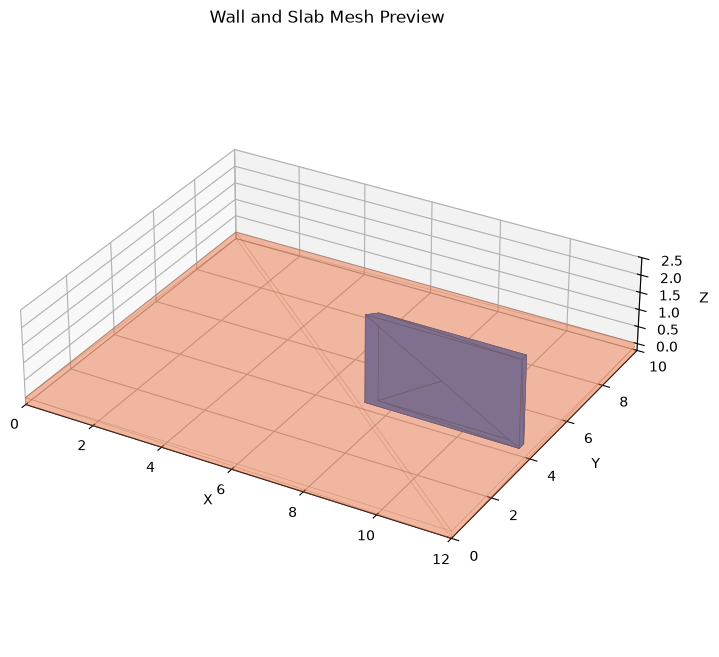

In [9]:
# Extract mesh and render both elements together
wall_verts, wall_tris = get_mesh(wall_shape)
slab_verts, slab_tris = get_mesh(slab_shape)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# Colors follow the shared categorical palette (blue = slot 1, orange = slot 2)
slab_mesh = Poly3DCollection(
    slab_tris, alpha=0.25, facecolor="#eb6834", edgecolor="#a4471f", linewidth=0.3
)
wall_mesh = Poly3DCollection(
    wall_tris, alpha=0.95, facecolor="#2a78d6", edgecolor="#184f95", linewidth=0.5
)

ax.add_collection3d(slab_mesh)
ax.add_collection3d(wall_mesh)

all_verts = np.vstack([wall_verts, slab_verts])

ax.set_xlim(all_verts[:, 0].min(), all_verts[:, 0].max())
ax.set_ylim(all_verts[:, 1].min(), all_verts[:, 1].max())
ax.set_zlim(all_verts[:, 2].min(), all_verts[:, 2].max())

ax.set_box_aspect([
    max(np.ptp(all_verts[:, 0]), 1e-3),
    max(np.ptp(all_verts[:, 1]), 1e-3),
    max(np.ptp(all_verts[:, 2]), 1e-3)
])

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Wall and Slab Mesh Preview")

plt.show()